
Running Attack with c=100
Original Label: 2
Adversarial Label: 1
L2 Perturbation: 3.31717443
Attack Successful! ✅


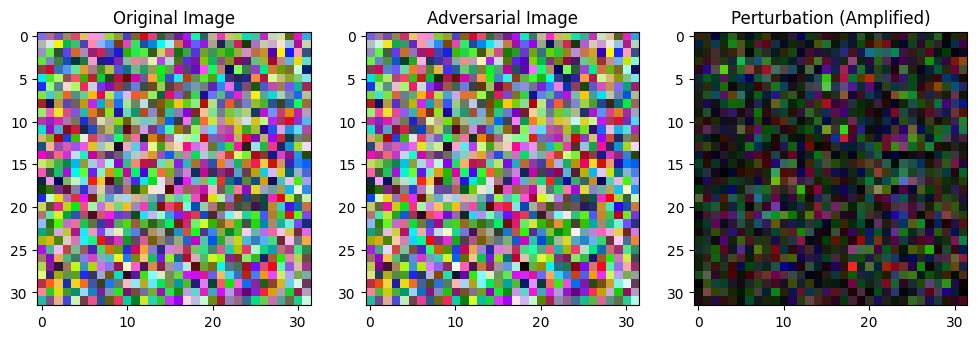


Running Attack with c=300
Original Label: 2
Adversarial Label: 2
L2 Perturbation: 3.58697772
Attack Failed ❌


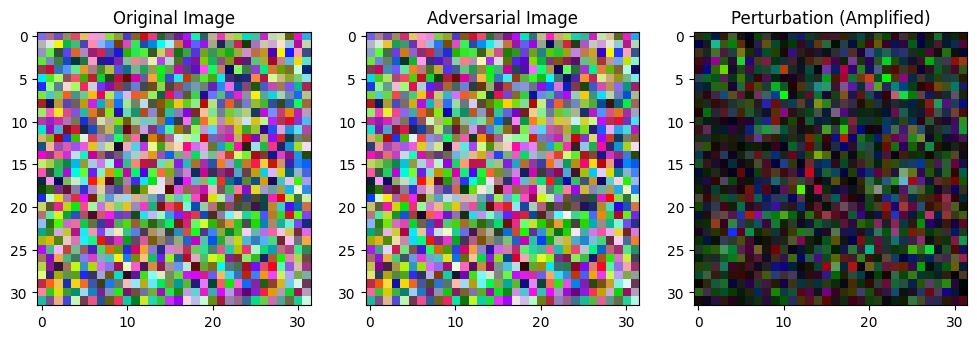


Running Attack with c=500
Original Label: 2
Adversarial Label: 1
L2 Perturbation: 3.66359043
Attack Successful! ✅


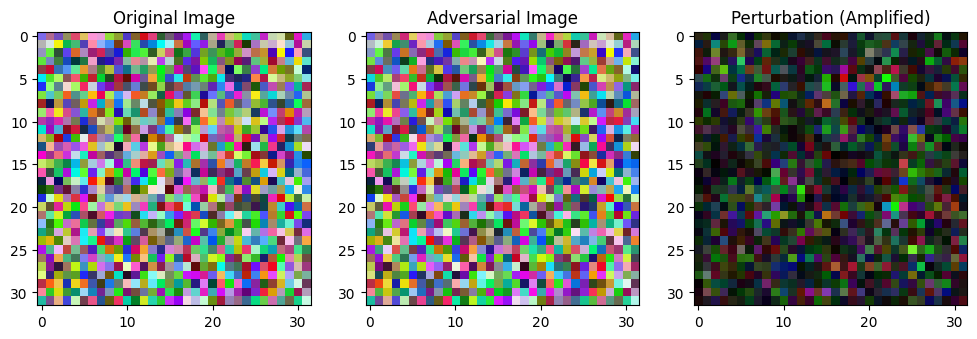

In [1]:
import torch
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
import torch.optim.lr_scheduler as lr_scheduler

# def cw_loss(output, y, confidence=0):
#     """
#     CW 目标函数: 让目标类别的 logit 小于非目标类别最大 logit - confidence
#     """
#     y_onehot = torch.zeros_like(output)
#     y_onehot.scatter_(1, y.view(-1, 1), 1)  # 生成 one-hot 编码

#     correct_logit = (output * y_onehot).sum(dim=1)  # 真实类别 logit
#     wrong_logit = ((1 - y_onehot) * output - 1e4 * y_onehot).max(dim=1)[0]  # 最大错误类别 logit

#     loss = torch.clamp(wrong_logit - correct_logit + confidence, min=0)  # f(x')
#     return loss.mean()

def cw_loss(output, y, confidence=0):
    """
    CW 目标函数: 让目标类别的 logit 小于非目标类别最大 logit - confidence
    """
    y_onehot = torch.zeros_like(output)
    y_onehot.scatter_(1, y.view(-1, 1), 1)  # 生成 one-hot 编码

    correct_logit = (output * y_onehot).sum(dim=1)  # 真实类别 logit
    wrong_logit = torch.where(y_onehot.bool(), float('-inf'), output).max(dim=1)[0]  # 最大错误类别 logit

    loss = F.relu(wrong_logit - correct_logit + confidence)  # 允许梯度流动
    return loss.sum()  # 用 sum 而不是 mean，提高攻击效果

def cw_attack(model, x, y, confidence=0, c=1e-2, max_iter=1000, learning_rate=1e-2):
    """
    CW-L2 攻击: 最小化 L2 扰动，同时让 x_adv 误分类
    """
    w = torch.zeros_like(x).detach().requires_grad_(True)  # 变量 w
    # w = torch.randn_like(x) * 0.1  # **增加初始扰动**
    # w.requires_grad_(True)
    optimizer = optim.Adam([w], lr=learning_rate)
    # scheduler = lr_scheduler.StepLR(optimizer, step_size=max_iter // 10, gamma=0.5)  
    # # **每 1/5 迭代次数，学习率乘 0.5**

    def transform(w):
        return 0.5 * (torch.tanh(w) + 1)  # 约束到 [0,1] 范围

    best_adv = x.clone()
    best_l2 = float('inf')

    for i in range(max_iter):
        x_adv = transform(w)  # 计算对抗样本
        output = model(x_adv)  # 计算 logits
        loss1 = torch.norm(x_adv - x, p=2)  # L2 扰动
        loss2 = cw_loss(output, y, confidence)
        loss = loss1 + c * loss2  # 总损失
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        # scheduler.step()  # **更新学习率**

        # 记录最优对抗样本
        # if loss2.item() == 1e-3 and 
        if loss1.item() < best_l2: # **仅依赖 L2 进行更新**
            # print(f"✅ Updating best_adv at iteration {i}, L2: {loss1.item():.5f}")
            best_adv = x_adv.detach()
            best_l2 = loss1.item()

        # if i % 100 == 0:
        #     print(f"Iteration {i}: Loss={loss.item():.5f}, L2={loss1.item():.8f}")

    # **优化结束后检查 best_adv 是否更新**
    if torch.norm(best_adv - x, p=2).item() == 0:
        print("⚠ Warning: best_adv was never updated, returning final x_adv instead.")
        return x_adv
    return best_adv

def evaluate_attack(model, x, x_adv, y):
    """
    评估攻击:
    1. 是否误分类
    2. 计算 L2 扰动大小
    """
    model.eval()
    with torch.no_grad():
        y_pred = model(x).argmax(dim=1).item()
        y_pred_adv = model(x_adv).argmax(dim=1).item()

    perturbation = torch.norm(x_adv - x, p=2).item()

    print(f"Original Label: {y_pred}")
    print(f"Adversarial Label: {y_pred_adv}")
    print(f"L2 Perturbation: {perturbation:.8f}")

    success = y_pred != y_pred_adv
    if success:
        print("Attack Successful! ✅")
    else:
        print("Attack Failed ❌")

    return success, perturbation

def visualize_attack(x, x_adv):
    """
    可视化原始样本、对抗样本及其扰动
    """
    x_np = x.squeeze(0).detach().cpu().numpy().transpose(1, 2, 0)  # (H, W, C)
    x_adv_np = x_adv.squeeze(0).detach().cpu().numpy().transpose(1, 2, 0)
    perturbation = np.abs(x_adv_np - x_np)  # 计算扰动

    # **归一化扰动，增强可视化**
    perturbation /= (perturbation.max() + 1e-8)

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))

    axes[0].imshow(np.clip(x_np, 0, 1))
    axes[0].set_title("Original Image")

    axes[1].imshow(np.clip(x_adv_np, 0, 1))
    axes[1].set_title("Adversarial Image")

    axes[2].imshow(perturbation, cmap="inferno")
    axes[2].set_title("Perturbation (Amplified)")

    plt.show()

# 运行攻击
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# CNN 模型
class SimpleCNN(torch.nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = torch.nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.conv2 = torch.nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.fc1 = torch.nn.Linear(32 * 8 * 8, 128)
        self.fc2 = torch.nn.Linear(128, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.max_pool2d(x, 2)
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2)
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# 初始化模型
model = SimpleCNN().to(device)

# 生成样本
x = torch.rand((1, 3, 32, 32)).to(device)
y = model(x).argmax(dim=1).item()  # 获取原始类别
y_target = torch.randint(0, 10, (1,)).to(device)
while y_target == y:  # 确保目标类别不同
    y_target = torch.randint(0, 10, (1,)).to(device)

# # 运行 CW 攻击
# x_adv = cw_attack(model, x, y_target, confidence=0, c=1e-2, max_iter=1000, learning_rate=1e-2)

# # 评估攻击效果
# evaluate_attack(model, x, x_adv, y_target)

# # 可视化攻击
# visualize_attack(x, x_adv)

c_values = [100, 300, 500]
for c in c_values:
    print(f"\nRunning Attack with c={c}")
    x_adv = cw_attack(model, x, y_target, confidence=0, c=c, max_iter=2000, learning_rate=1e-2)
    evaluate_attack(model, x, x_adv, y_target)
    visualize_attack(x, x_adv)



Running Attack with c=100
Original Label: 2
Adversarial Label: 2
L2 Perturbation: 0.21959746
Attack Failed ❌
Original Label: 2
Adversarial Label: 1
L2 Perturbation: 2.46798491
Attack Successful! ✅


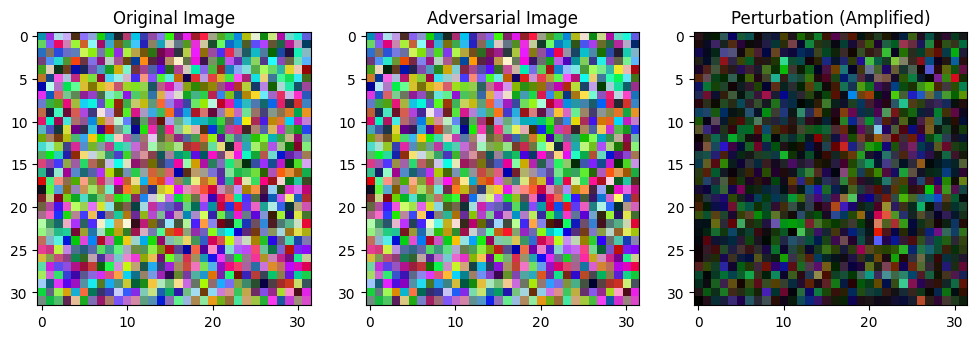

Original Label: 2
Adversarial Label: 2
L2 Perturbation: 2.18795204
Attack Failed ❌
Original Label: 2
Adversarial Label: 2
L2 Perturbation: 0.95972568
Attack Failed ❌
Original Label: 2
Adversarial Label: 2
L2 Perturbation: 1.22940087
Attack Failed ❌
Original Label: 2
Adversarial Label: 1
L2 Perturbation: 3.62397885
Attack Successful! ✅


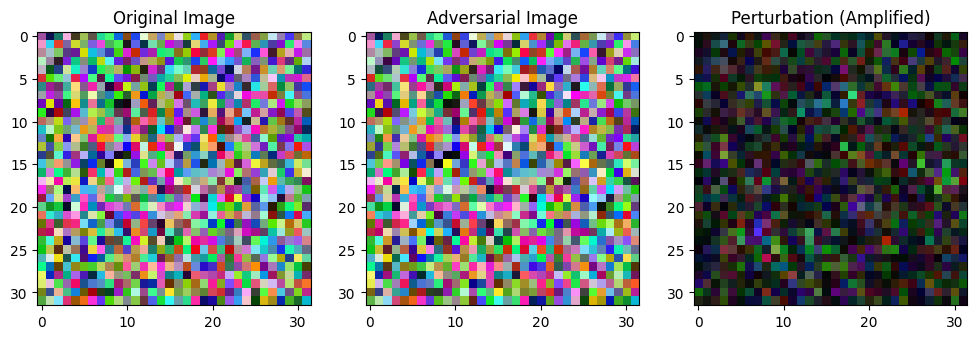

Original Label: 2
Adversarial Label: 1
L2 Perturbation: 1.29443467
Attack Successful! ✅


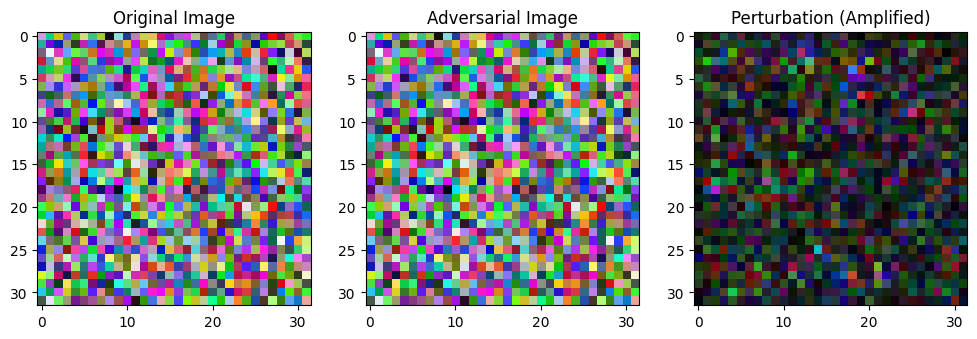

Original Label: 2
Adversarial Label: 2
L2 Perturbation: 0.92599535
Attack Failed ❌
Original Label: 2
Adversarial Label: 1
L2 Perturbation: 2.63474202
Attack Successful! ✅


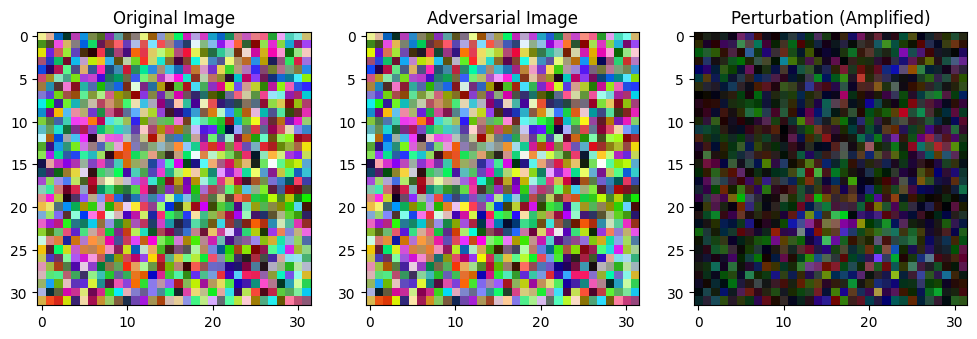

Original Label: 2
Adversarial Label: 2
L2 Perturbation: 1.81529486
Attack Failed ❌
Average L2 Perturbation for c=100: 1.73591
Attack Success Rate for c=100: 40.00%

Running Attack with c=300
Original Label: 2
Adversarial Label: 2
L2 Perturbation: 1.29709136
Attack Failed ❌
Original Label: 2
Adversarial Label: 2
L2 Perturbation: 1.18110716
Attack Failed ❌
Original Label: 2
Adversarial Label: 1
L2 Perturbation: 1.36114430
Attack Successful! ✅


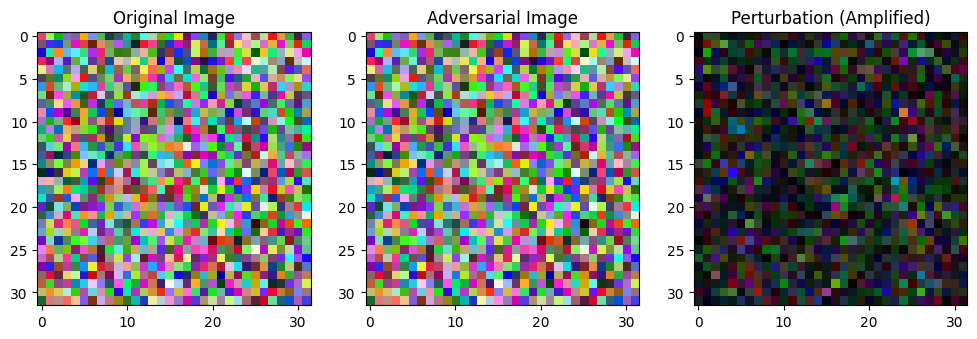

Original Label: 2
Adversarial Label: 2
L2 Perturbation: 1.52356303
Attack Failed ❌
Original Label: 2
Adversarial Label: 4
L2 Perturbation: 3.69300604
Attack Successful! ✅


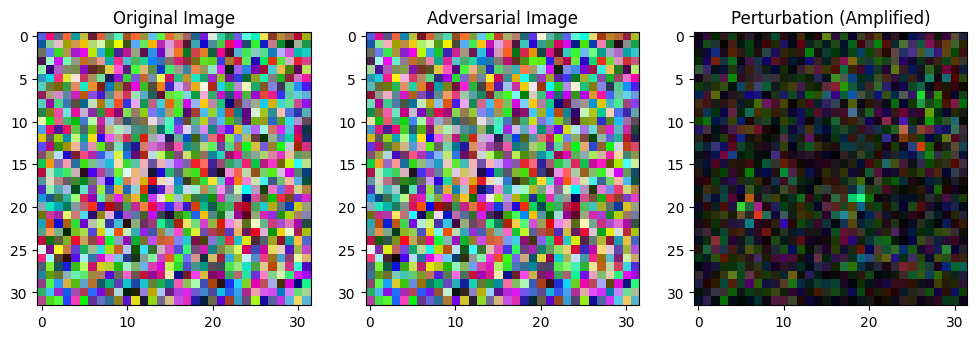

Original Label: 2
Adversarial Label: 1
L2 Perturbation: 1.33202195
Attack Successful! ✅


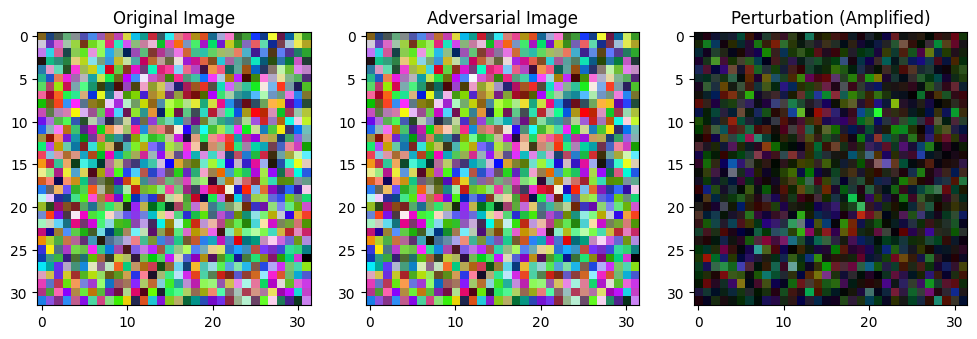

Original Label: 2
Adversarial Label: 2
L2 Perturbation: 3.12269330
Attack Failed ❌
Original Label: 2
Adversarial Label: 2
L2 Perturbation: 2.14788580
Attack Failed ❌
Original Label: 2
Adversarial Label: 1
L2 Perturbation: 3.43175340
Attack Successful! ✅


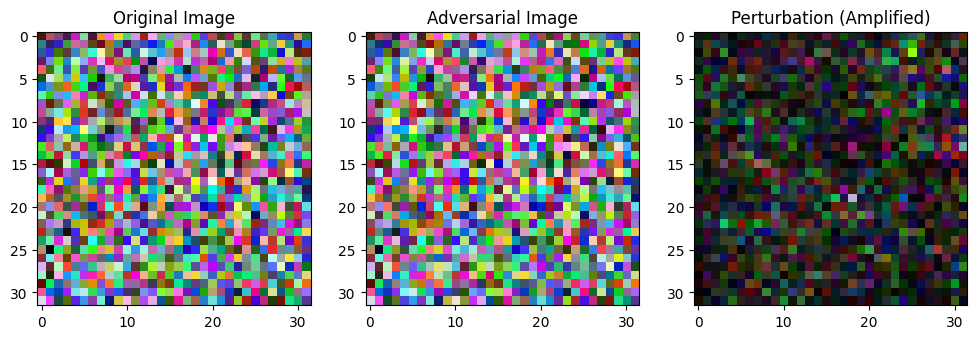

Original Label: 2
Adversarial Label: 2
L2 Perturbation: 1.25074232
Attack Failed ❌
Average L2 Perturbation for c=300: 2.03410
Attack Success Rate for c=300: 40.00%

Running Attack with c=500
Original Label: 2
Adversarial Label: 2
L2 Perturbation: 1.32656622
Attack Failed ❌
Original Label: 2
Adversarial Label: 1
L2 Perturbation: 3.51368952
Attack Successful! ✅


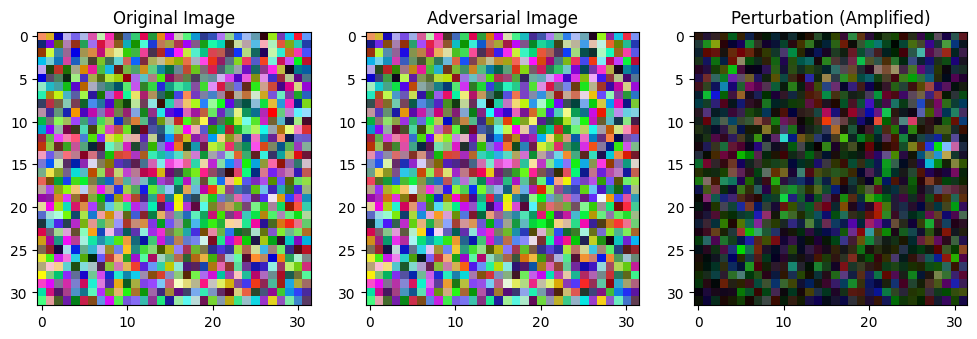

Original Label: 2
Adversarial Label: 1
L2 Perturbation: 2.72566819
Attack Successful! ✅


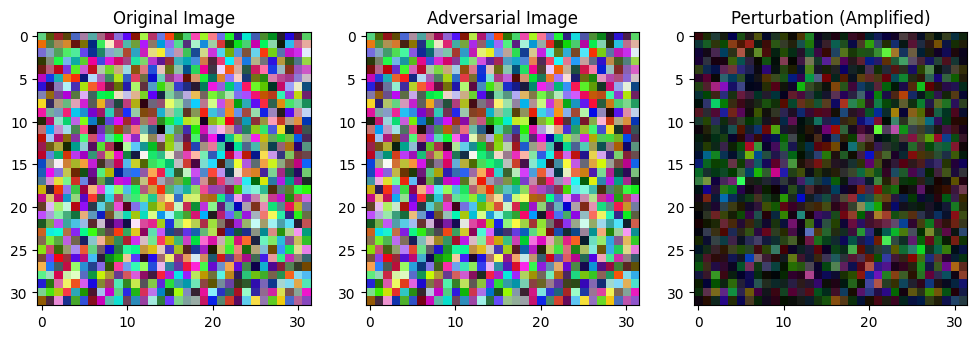

Original Label: 2
Adversarial Label: 2
L2 Perturbation: 1.39128947
Attack Failed ❌
Original Label: 2
Adversarial Label: 2
L2 Perturbation: 3.84898973
Attack Failed ❌
Original Label: 2
Adversarial Label: 1
L2 Perturbation: 4.02234745
Attack Successful! ✅


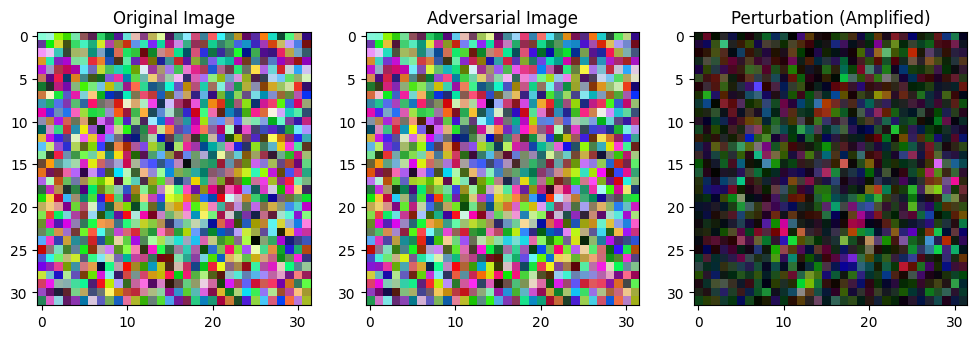

Original Label: 2
Adversarial Label: 2
L2 Perturbation: 2.04241014
Attack Failed ❌
Original Label: 2
Adversarial Label: 1
L2 Perturbation: 1.66291344
Attack Successful! ✅


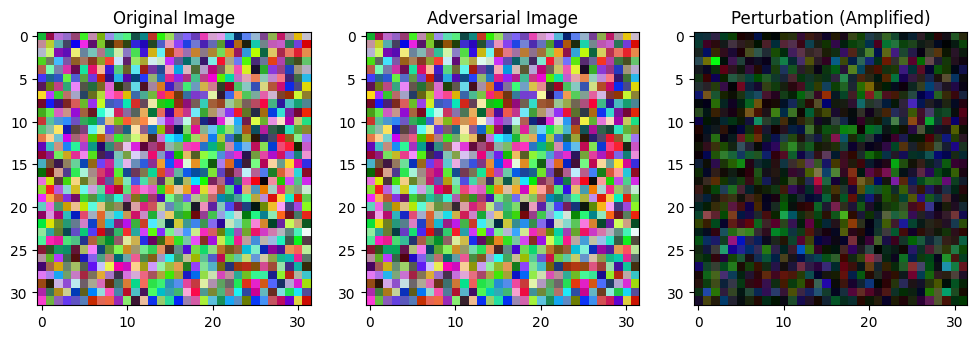

Original Label: 2
Adversarial Label: 2
L2 Perturbation: 1.95379519
Attack Failed ❌
Original Label: 2
Adversarial Label: 2
L2 Perturbation: 1.25579095
Attack Failed ❌
Average L2 Perturbation for c=500: 2.37435
Attack Success Rate for c=500: 40.00%


In [3]:
# c = 100
for c in c_values:
    success_count = 0
    num_samples = 10
    perturbations = []
    print(f"\nRunning Attack with c={c}")
    for i in range(num_samples):
        x = torch.rand((1, 3, 32, 32)).to(device)
        y = model(x).argmax(dim=1).item()  # 获取原始类别
        y_target = torch.randint(0, 10, (1,)).to(device)
        while y_target == y:  # 确保目标类别不同
            y_target = torch.randint(0, 10, (1,)).to(device)
        x_adv = cw_attack(model, x, y_target, confidence=0, c=c, max_iter=2000, learning_rate=1e-2)
        success, perturbation = evaluate_attack(model, x, x_adv, y_target)
        
        if success:
            success_count += 1
            visualize_attack(x, x_adv)
        perturbations.append(perturbation)
    print(f"Average L2 Perturbation for c={c}: {sum(perturbations) / num_samples:.5f}")
    print(f"Attack Success Rate for c={c}: {success_count / num_samples * 100:.2f}%")
    # print(f"Average L2 Perturbation: {sum(perturbations) / num_samples:.5f}")
    # print(f"Attack Success Rate: {success_count / num_samples * 100:.2f}%")